In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [2]:
X,y = make_regression(n_samples = 100 , n_features = 1 , n_targets = 1 , noise = 30 , random_state = 42)

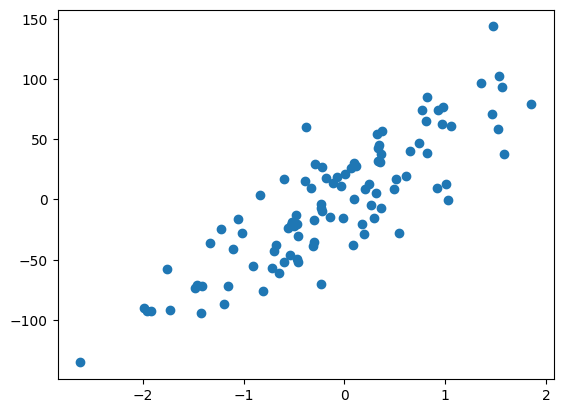

In [3]:
plt.scatter(X,y)

In [4]:
print(X.shape)
print(y.shape)

(100, 1)
(100,)


In [5]:
X_train ,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [6]:
# creating class
class MyGDRegressor:

  def __init__(self, learning_rate  , epochs ):
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.coef_ = 0
    self.intercept_ = 0
    self.loss_history = []   # for storing loss after each iteration(epoch)


  def fit(self,X,y):
        for i in range(self.epochs):

            y_pred = self.coef_ * X.ravel() + self.intercept_

            loss = np.mean((y - y_pred) ** 2)
            self.loss_history.append(loss)


            loss_slope_b = -2*np.mean(y-self.coef_*X.ravel() -self.intercept_)
            loss_slope_m = -2*np.mean((y- self.coef_*X.ravel() -self.intercept_)*X.ravel())

            self.intercept_ = self.intercept_ - (self.learning_rate * loss_slope_b)
            self.coef_ = self.coef_ - (self.learning_rate * loss_slope_m)

        print(f"coefficient is : {self.coef_} and intercept is : {self.intercept_}")

  def predict(self , X):
        return self.coef_*X.ravel() +self.intercept_



In [7]:
gd = MyGDRegressor(0.01,1000)

In [8]:
gd.fit(X_train,y_train)

coefficient is : 49.250338035080716 and intercept is : 0.2976623965747907


In [9]:
y_test_pred = gd.predict(X_test)

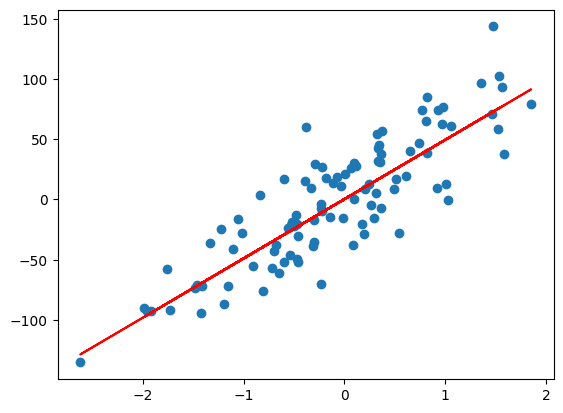

In [10]:
# visualizing dataset and fitted model
plt.scatter(X,y)
plt.plot(X_train,gd.predict(X_train), color = 'red')
plt.show()

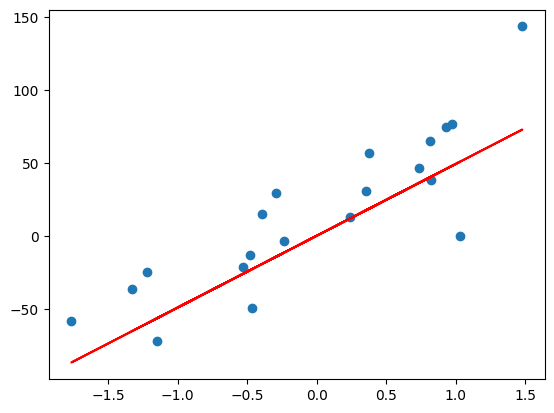

In [11]:
# visualising test data and fitted model
plt.scatter(X_test,y_test)
plt.plot(X_test,y_test_pred, color = 'red')
plt.show()

In [12]:
gd_1 = MyGDRegressor(learning_rate = 0.001 , epochs = 100)
gd_1.fit(X_train,y_train)

coefficient is : 7.55514751324095 and intercept is : -1.0028666448657433


In [13]:
gd_2 = MyGDRegressor(learning_rate = 0.01 , epochs = 100)
gd_2.fit(X_train,y_train)

coefficient is : 39.80413739665213 and intercept is : -1.8023552865377999


In [14]:
gd_3 = MyGDRegressor(learning_rate = 0.1 , epochs = 100)
gd_3.fit(X_train,y_train)

coefficient is : 49.2503434520628 and intercept is : 0.29766534192324084


In [15]:
gd_4 = MyGDRegressor(learning_rate = 0.05 , epochs = 100)
gd_4.fit(X_train,y_train)

coefficient is : 49.23677256877565 and intercept is : 0.29058468179247715


In [16]:
gd_5 = MyGDRegressor(learning_rate = 0.02 , epochs = 100)
gd_5.fit(X_train,y_train)

coefficient is : 47.40169524526129 and intercept is : -0.3763750582871237


In [17]:
models = [gd_1 ,gd_2 ,gd_3 , gd_4 ,gd_5]

for model in models:
    m = model
    m.fit(X_train, y_train)
    final = m.loss_history[-1]
    print(f"first_loss={m.loss_history[0]:.4f}, final_loss={final}\n")

coefficient is : 13.928814351807057 and intercept is : -1.6619380504962669
first_loss=2676.4094, final_loss=1686.7239813520996

coefficient is : 47.353155030447745 and intercept is : -0.38646316354474103
first_loss=2676.4094, final_loss=659.5393608504927

coefficient is : 49.250345838166666 and intercept is : 0.2976666426775568
first_loss=2676.4094, final_loss=656.3027509292966

coefficient is : 49.25034109467304 and intercept is : 0.29766405890606584
first_loss=2676.4094, final_loss=656.3027509293227

coefficient is : 49.17196331763566 and intercept is : 0.2591168563822836
first_loss=2676.4094, final_loss=656.3089597423174



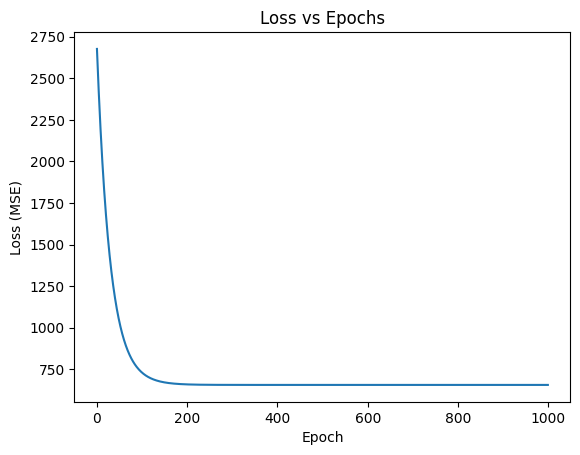

In [18]:
# Ploting the Loss (Cost) vs Epochs graph to visualize convergence
plt.plot(gd.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs")
plt.show()

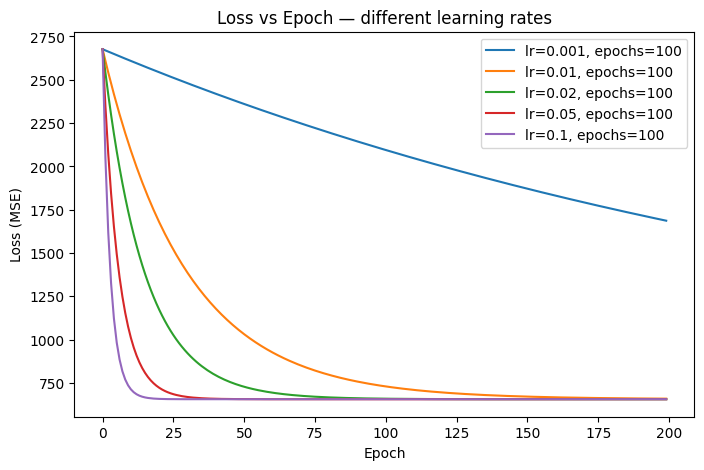

In [19]:
# experimenting with different learning raet and epochs
plt.figure(figsize=(8,5))
plt.plot(gd_1.loss_history, label='lr=0.001, epochs=100')
plt.plot(gd_2.loss_history, label='lr=0.01, epochs=100')
plt.plot(gd_5.loss_history, label='lr=0.02, epochs=100')
plt.plot(gd_4.loss_history, label='lr=0.05, epochs=100')
plt.plot(gd_3.loss_history, label='lr=0.1, epochs=100')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss vs Epoch — different learning rates')
plt.legend()
plt.show()

coefficient is : 49.23192372539889 and intercept is : 0.28820803407923584


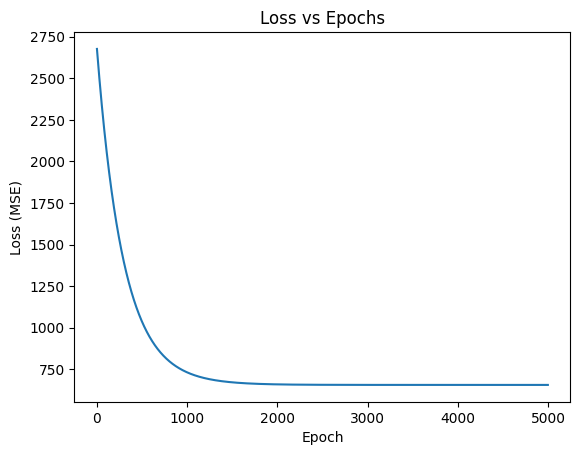

In [20]:

gd_1 = MyGDRegressor(learning_rate = 0.001 , epochs = 5000)
gd_1.fit(X_train,y_train)
plt.plot(gd_1.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs")
plt.show()

In [21]:
print("Train MAE : " , mean_absolute_error(y_train ,gd.predict(X_train)))
print("Train MSE : " , mean_squared_error(y_train ,gd.predict(X_train)))
print("Train RSME : " , np.sqrt(mean_squared_error(y_train ,gd.predict(X_train))))
print('Train r2 score : ' ,r2_score(y_train ,gd.predict(X_train)))

Train MAE :  20.52750579733962
Train MSE :  656.3027509293569
Train RSME :  25.6184064869257
Train r2 score :  0.7513952585977766


In [22]:
print("Test MAE : " , mean_absolute_error(y_test ,y_test_pred))
print("Test MSE : " , mean_squared_error(y_test,y_test_pred))
print("Test RSME : " , np.sqrt(mean_squared_error(y_test,y_test_pred)))
print("Test r2 score : " ,r2_score(y_test,y_test_pred))

Test MAE :  25.24998209398678
Test MSE :  937.8201834744444
Test RSME :  30.62384991268153
Test r2 score :  0.6538825622173032


In [23]:
#improving my model for multiple features :

class MyGDRegressorMulti:

  def __init__(self,learning_rate,epochs):
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.coef_ = None
    self.intercept_ = None

  def fit(self,X,y):
    self.intercept_ = 0
    self.coef_ = np.ones(X.shape[1])


    for i in range(self.epochs):
      y_hat = np.dot(X,self.coef_) + self.intercept_

      intercept_der = -2 * np.mean(y-y_hat)
      self.intercept_ = self.intercept_ - (self.learning_rate * intercept_der)

      coef_der = -2 * np.dot((y-y_hat),X)/X.shape[0]
      self.coef_ = self.coef_ - (self.learning_rate * coef_der)

    print(f"Intercept: {self.intercept_} and coefficients : {self.coef_}")

  def predict(self,X):
      return np.dot(X,self.coef_) + self.intercept_

In [24]:
gd = MyGDRegressorMulti(0.01,100)
gd.fit(X_train,y_train)

Intercept: -1.760547900935862 and coefficients : [39.99568455]


In [25]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias= True)
X_train_poly = poly.fit_transform(X_train)   # fit_transform only on train
X_test_poly = poly.transform(X_test)

In [26]:
gd_poly = MyGDRegressorMulti(0.01, 100)

In [27]:
print("X_train_poly:", X_train_poly.shape)
print("y_train:", y_train.shape)

X_train_poly: (80, 3)
y_train: (80,)


In [28]:
gd_poly.fit(X_train_poly, y_train)

Intercept: 0.514950512113683 and coefficients : [ 1.51495051 38.45014671 -4.0124679 ]


In [29]:
y_test_pred_poly = gd_poly.predict(X_test_poly)

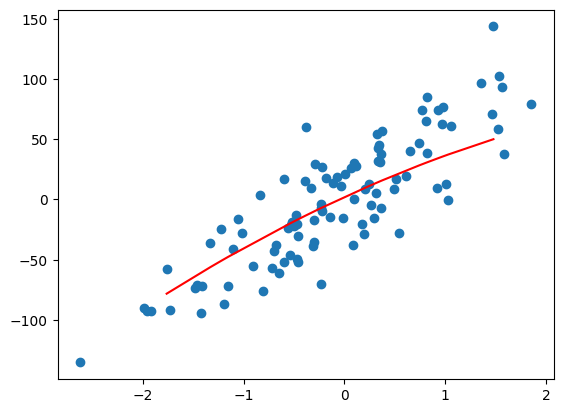

In [30]:
sort_idx = np.argsort(X_test.ravel())
X_test_sorted = X_test[sort_idx]
y_test_pred_poly_sorted = y_test_pred_poly[sort_idx]

plt.scatter(X, y)
plt.plot(X_test_sorted, y_test_pred_poly_sorted, color='red')
plt.show()

In [31]:
print("Linera Regression")
print("Test MAE : " , mean_absolute_error(y_test ,y_test_pred))
print("Test MSE : " , mean_squared_error(y_test,y_test_pred))
print("Test RSME : " , np.sqrt(mean_squared_error(y_test,y_test_pred)))
print("Test r2 score : " ,r2_score(y_test,y_test_pred))

Linera Regression
Test MAE :  25.24998209398678
Test MSE :  937.8201834744444
Test RSME :  30.62384991268153
Test r2 score :  0.6538825622173032


In [32]:
print("Polynomial Regression(Degree = 2) on TRain Dataset")
print("Train MAE : " , mean_absolute_error(y_train ,gd_poly.predict(X_train_poly)))
print("Train MSE : " , mean_squared_error(y_train ,gd_poly.predict(X_train_poly)))
print("Train RSME : " , np.sqrt(mean_squared_error(y_train ,gd_poly.predict(X_train_poly))))
print('Train r2 score : ' ,r2_score(y_train ,gd_poly.predict(X_train_poly)))

Polynomial Regression(Degree = 2) on TRain Dataset
Train MAE :  22.308324804799327
Train MSE :  737.8985444426932
Train RSME :  27.164288034894145
Train r2 score :  0.7204871127501972


In [33]:
print("Polynomial Regression (Degree = 2) on Test Dataset ")
print("Test MAE : " , mean_absolute_error(y_test ,y_test_pred_poly))
print("Test MSE : " , mean_squared_error(y_test,y_test_pred_poly))
print("Test RSME : " , np.sqrt(mean_squared_error(y_test,y_test_pred_poly)))
print("Test r2 score : " ,r2_score(y_test,y_test_pred_poly))

Polynomial Regression (Degree = 2) on Test Dataset 
Test MAE :  26.711006498722593
Test MSE :  1132.3920062413763
Test RSME :  33.65103276634131
Test r2 score :  0.5820727398787606
